In [1]:
# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u
from matplotlib import pyplot as plt

In [7]:
# Constants
G = 6.674e-8        # cm^3 g^-1 s^-2
sigmaB = 5.67e-5    # erg cm^-2 s^-1 K^-4
kB = 1.381e-16      # erg/K
L_sun = 3.828e33    # erg/s
R_p = 7.149e9       # Jupiter radius in cm
AU = 1.496e13       # cm

# Physical constants
M_jup = 1.898e30
R_jup = 7.149e9
AU = 1.496e13
sec_per_yr = 3.156e7

In [13]:

def calculate_disk_properties(Mp, Mdot, alpha, kappaR, Rin, Rout, d_pc, 
                            mode="b", kappa_mm=1.0, lam_mm=1.3e-1, 
                            T_ISM=10.0, Lplanet=0.0, mu=2.3):
    """
    Calculate disk temperature profiles and millimeter flux.
    
    Parameters:
    -----------
    Mp : float
        Planet mass (g)
    Mdot : float  
        Accretion rate (g/s)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rin : float
        Inner radius (cm)
    Rout : float
        Outer radius (cm)  
    d_pc : float
        Distance (pc)
    mode : str
        Irradiation mode: "b", "no_b", or "planet"
    kappa_mm : float
        Millimeter opacity (cm^2/g)
    lam_mm : float
        Wavelength (cm)
    T_ISM : float
        Interstellar medium temperature (K)
    Lplanet : float
        Planet luminosity (erg/s)
    mu : float
        Mean molecular weight
        
    Returns:
    --------
    dict : Dictionary containing R, temperatures, Sigma, tau_mm, Tb, F_nu_tot
    """
    
    # 1. Create radial grid between Rin and Rout
    R = np.geomspace(Rin, Rout, 100)  # cm
    
    # 2. Calculate T_ext(R)
    if mode == "b":
        L_irr = G * Mp * Mdot / (2.0 * R_p)
    elif mode == "no_b":
        L_irr = 0.0
    elif mode == "planet":
        L_irr = Lplanet
    else:
        raise ValueError("mode must be 'b', 'no_b', or 'planet'")
    
    T_irr = 0.0 if L_irr == 0.0 else (L_irr / (40 * np.pi * sigmaB * R**2))**0.25
    
    print(f'L_irr = {L_irr/L_sun:.2e} L_sun')
    
    T_ext = (T_irr**4 + T_ISM**4)**0.25  # K
    
    # 3. Calculate T_eff(R)
    Teff = ((3.0 * G * Mp * Mdot) / (8.0 * np.pi * sigmaB * R**3) * 
            (1.0 - np.sqrt(Rin / R)))**0.25  # K
    
    # 4. Calculate Sigma(R)
    Rgas = 8.314e7  # erg/(mol K)
    
    # Sigma prescription 6 (optically thick)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)
    
    # Sigma prescription 7 (optically thin)
    Omega = np.sqrt(G * Mp / R**3)
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)  # g/cm^2
    
    # Take minimum of the two
    Sigma = np.minimum(Sigma6, Sigma7)
    
    # 5. Calculate T_c(R)
    A = (9 * G * Mp * Mdot * Sigma * kappaR) / (128 * np.pi * sigmaB * R**3)
    f = (1.0 - np.sqrt(Rin / R))
    T_c = (A * f + T_ext**4)**0.25
    
    # 6. Calculate T_b(R)
    # Convert to arrays for consistent handling
    Sigma = np.asarray(Sigma, dtype=float)
    T_c = np.asarray(T_c, dtype=float)
    Teff = np.asarray(Teff, dtype=float)
    T_ext = np.asarray(T_ext, dtype=float)
    
    if not (Sigma.shape == T_c.shape == Teff.shape == T_ext.shape):
        raise ValueError("Sigma, Tc, Teff, T_ext must have the same shape.")
    
    # τ_mm = 0.5 κ_mm Σ
    tau_mm = 0.5 * kappa_mm * Sigma
    
    # thin branch: Tb = 2 τ Tc
    Tb_thin = 2.0 * tau_mm * T_c
    
    # thick branch: Tb^4 = (3/8)*(κ_R/κ_mm)*Teff^4 + T_ext^4
    Tb_thick = ((3.0/8.0) * (kappaR / kappa_mm) * Teff**4 + T_ext**4)**0.25
    
    # hard switch at τ=0.5
    Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)
    
    # 7. Calculate Tb_avg over the disc
    dR = np.diff(R)
    Rmid = 0.5 * (R[:-1] + R[1:])
    Tbmid = 0.5 * (Tb[:-1] + Tb[1:])
    num = np.sum(Tbmid * 2 * np.pi * Rmid * dR)
    den = np.pi * (Rout**2 - Rin**2)
    Tb_avg = num / den
    
    # 8. Calculate F_nu in Rayleigh-Jeans limit, integrated over the disc area
    I_RJ = 2.0 * kB * Tb / (lam_mm)**2  # erg cm^-2 s^-1 Hz^-1 sr^-1
    F_nu = I_RJ  #np.pi  # erg s^-1 cm^-2 Hz^-1
    
    # Convert distance to cm and calculate flux
    pc_to_cm = 3.086e18  # cm/pc
    d_cm = d_pc * pc_to_cm
    
    # Total flux from disk area
    F_nu_mid = 0.5 * (F_nu[:-1] + F_nu[1:])
    F_nu_tot = np.sum(F_nu_mid * 2 * np.pi * Rmid * dR)
    
    # Convert to microJy at distance d
    F_nu_tot = F_nu_tot / d_cm**2 * 1e29  # microJy
    
    print(f'Tb_avg = {Tb_avg:.1f} K')
    print(f'F_nu_tot = {F_nu_tot:.2f} microJy')
    
    return {
        'R': R,
        'R_AU': R / AU,
        'T_ext': T_ext,
        'Teff': Teff,
        'T_c': T_c,
        'Tb': Tb,
        'Sigma': Sigma,
        'tau_mm': tau_mm,
        'F_nu_tot': F_nu_tot,
        'Tb_avg': Tb_avg
    }




In [37]:
def plot_disk_profiles(results, results_tb_085, results_tb_3, alpha, Mp_label, Mdot_label, save_plots=False):
    """
    Plot CPD surface density and temperature profiles,
    including brightness temperature overlays for 0.85mm and 3mm.

    Parameters
    ----------
    results : dict
        Dictionary returned by calculate_disk_properties (main wavelength).
    results_tb_085 : dict
        Dictionary for Tb at 0.85mm.
    results_tb_3 : dict
        Dictionary for Tb at 3mm.
    alpha : float
        Viscosity parameter for annotation.
    Mp_label : str
        Planet mass label for annotation.
    Mdot_label : str
        Accretion rate label for annotation.
    save_plots : bool
        Whether to save plots to file.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: log10(Sigma) vs log10(R/AU)
    ax1.plot(np.log10(results['R_AU']), np.log10(results['Sigma']), color='k')
    ax1.set_xlabel(r'$\log_{10}(R/\mathrm{AU})$')
    ax1.set_ylabel(r'$\log_{10}\Sigma\,(\mathrm{g\,cm}^{-2})$')
    
    ax1.set_xlim(-3.6, 0.5)
    #ax1.set_ylim(1.5, 4.3)

    # Panel 2: log10(Temperature) vs log10(R/AU)
    ax2.plot(np.log10(results['R_AU']), np.log10(results['Teff']), color='b', label=r'$T_{\rm eff}$', linewidth=2)
    ax2.plot(np.log10(results['R_AU']), np.log10(results['T_c']), color='r', label=r'$T_c$', linewidth=2)
    ax2.plot(np.log10(results_tb_085['R_AU']), np.log10(results_tb_085['Tb']), 'k--', label=r'$T_b(0.85\,\mathrm{mm})$', linewidth=2)
    ax2.plot(np.log10(results_tb_3['R_AU']), np.log10(results_tb_3['Tb']), 'k:', label=r'$T_b(3\,\mathrm{mm})$', linewidth=2)
    ax2.set_xlabel(r'$\log_{10}(R/\mathrm{AU})$')
    ax2.set_ylabel(r'$\log_{10}T\,(\mathrm{K})$')
    ax2.set_xlim(-3.6, 0.5)
    #ax2.set_ylim(0.0, 4.5)
    #ax2.set_title(r'Circumplanetary disc detection', loc='center', fontsize=20)
    ax2.annotate(f'{Mp_label}\n{Mdot_label}\n$\\alpha = {alpha}$',
                 xy=(-0.9, 4.2), xycoords='data', fontsize=13,
                 bbox=dict(boxstyle="round,pad=0.3", fc="w", ec="gray", alpha=0.7))
    ax2.legend(loc='lower left', fontsize=12, frameon=False)


    plt.tight_layout()
    if save_plots:
        plt.savefig('cpd_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()


kappa_mm_dict = {                       
    "0.85mm": 0.034 * (0.87/0.85)**1.7,    # Input: 0.85mm → Output: 0.036 cm^2/g
    "1.3mm": 0.034 * (0.87/1.3)**1.7,      # Input: 1.3mm → Output: 0.018 cm^2/g  
    "3mm": 0.034 * (0.87/3)**1.7,          # Input: 3mm → Output: 0.0024 cm^2/g
    "10mm": 0.034 * (0.87/10)**1.7         # Input: 10mm → Output: 0.00024 cm^2/g
}




L_irr = 1.39e-03 L_sun
Tb_avg = 61.2 K
F_nu_tot = 1290.27 microJy
L_irr = 1.39e-03 L_sun
Tb_avg = 54.1 K
F_nu_tot = 2666.19 microJy
L_irr = 1.39e-03 L_sun
Tb_avg = 51.9 K
F_nu_tot = 205.14 microJy


C:\Users\LHEM\AppData\Local\Temp\ipykernel_21060\2483527025.py:26: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(results['R_AU']), np.log10(results['Sigma']), color='k')
C:\Users\LHEM\AppData\Local\Temp\ipykernel_21060\2483527025.py:34: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(results['R_AU']), np.log10(results['Teff']), color='b', label=r'$T_{\rm eff}$', linewidth=2)
C:\Users\LHEM\AppData\Local\Temp\ipykernel_21060\2483527025.py:36: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(results_tb_085['R_AU']), np.log10(results_tb_085['Tb']), 'k--', label=r'$T_b(0.85\,\mathrm{mm})$', linewidth=2)
C:\Users\LHEM\AppData\Local\Temp\ipykernel_21060\2483527025.py:37: RuntimeWarning: divide by zero encountered in log10
  ax2.plot(np.log10(results_tb_3['R_AU']), np.log10(results_tb_3['Tb']), 'k:', label=r'$T_b(3\,\mathrm{mm})$', linewidth=2)


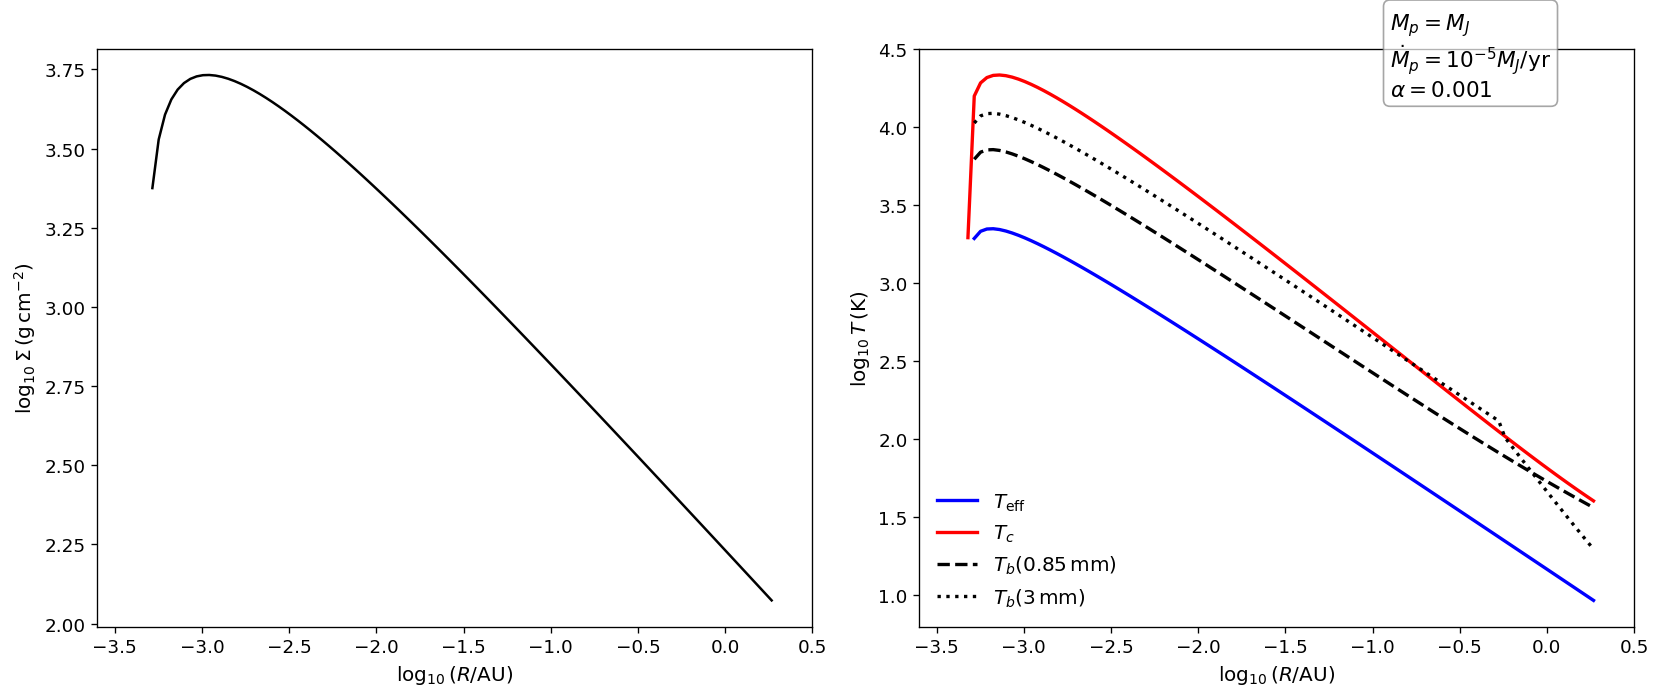

In [38]:
# Example usage with your parameters
if __name__ == "__main__":

    # Disk parameters
    Mp = 1.0 * M_jup
    Mdot = 1e-5 * M_jup / sec_per_yr
    alpha = 1e-3
    kappaR = 10.0
    Rin = 1.0 * R_jup
    Rout = 1.85 * AU
    d = 140

    Mp_label = r'$M_p = M_J$'
    Mdot_label = r'$\dot{M}_p = 10^{-5} M_J/\mathrm{yr}$'

    # Calculate for main wavelength (e.g., 1.3mm)
    results = calculate_disk_properties(Mp, Mdot, alpha, kappaR, Rin, Rout, d,
                                       kappa_mm=kappa_mm_dict["1.3mm"], lam_mm=0.13)
    # Calculate for 0.85mm
    results_tb_085 = calculate_disk_properties(Mp, Mdot, alpha, kappaR, Rin, Rout, d,
                                              kappa_mm=kappa_mm_dict["0.85mm"], lam_mm=0.085)
    # Calculate for 3mm
    results_tb_3 = calculate_disk_properties(Mp, Mdot, alpha, kappaR, Rin, Rout, d,
                                            kappa_mm=kappa_mm_dict["3mm"], lam_mm=0.3)

    # Plot
    plot_disk_profiles(results, results_tb_085, results_tb_3, alpha, Mp_label, Mdot_label)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_21060\2481694515.py:39: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(R/AU), np.log10(Sigma6), label=r'$\Sigma_6$ (thick)', color='b')


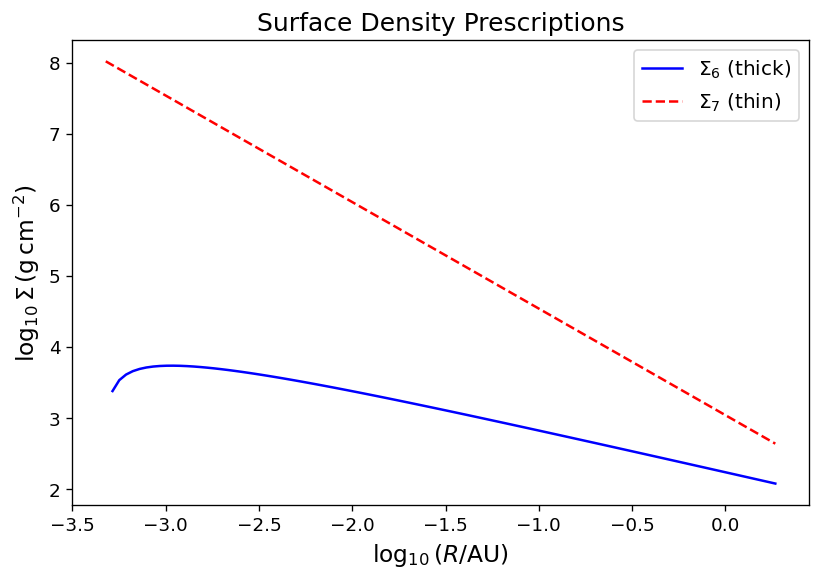

In [41]:
def plot_sigma6_vs_sigma7(Mp, Mdot, alpha, kappaR, Rin, Rout, mu=2.3):
    """
    Plot Sigma6 (optically thick) vs Sigma7 (optically thin) as a function of radius.

    Parameters
    ----------
    Mp : float
        Planet mass (g)
    Mdot : float
        Accretion rate (g/s)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rin : float
        Inner radius (cm)
    Rout : float
        Outer radius (cm)
    mu : float
        Mean molecular weight
    """
    Rgas = 8.314e7  # erg/(mol K)
    AU = 1.496e13   # cm

    R = np.geomspace(Rin, Rout, 100)
    # Sigma6 (optically thick)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * (np.pi**3) * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rin/R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)

    # Sigma7 (optically thin)
    Omega = np.sqrt(G * Mp / R**3)
    # For plotting, use T_ext = 10 K (ISM) as a simple reference
    T_ext = 10.0
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)

    plt.figure(figsize=(7,5))
    plt.plot(np.log10(R/AU), np.log10(Sigma6), label=r'$\Sigma_6$ (thick)', color='b')
    plt.plot(np.log10(R/AU), np.log10(Sigma7), label=r'$\Sigma_7$ (thin)', color='r', linestyle='--')
    plt.xlabel(r'$\log_{10}(R/\mathrm{AU})$', fontsize=14)
    plt.ylabel(r'$\log_{10}\Sigma\,(\mathrm{g\,cm}^{-2})$', fontsize=14)
    plt.title('Surface Density Prescriptions', fontsize=15)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_sigma6_vs_sigma7(Mp, Mdot, alpha, kappaR, Rin, Rout)

In [ ]:
l